In [9]:
# =============================================================================
# ANALYSE DE SURVIE DYNAMIQUE / DYNAMIC SURVIVAL ANALYSIS
# Projet: DPSP (Dynamic PSA Survival Predictor)
# Auteur: Michel Robitaille
# =============================================================================
"""
FR : Ce carnet démontre l'utilisation du modèle DPSP pour comparer deux scénarios 
cliniques : une progression du PSA (hausse) et une réponse au traitement (baisse).

EN : This notebook demonstrates the use of the DPSP model to compare two clinical 
scenarios: PSA progression (increase) and treatment response (decrease).
"""

import matplotlib.pyplot as plt
import numpy as np
import dpsp  # Import simplifié tel que configuré dans __init__.py

# Initialisation du modèle
model = dpsp.DynamicSurvivalModel(threshold=4.0)

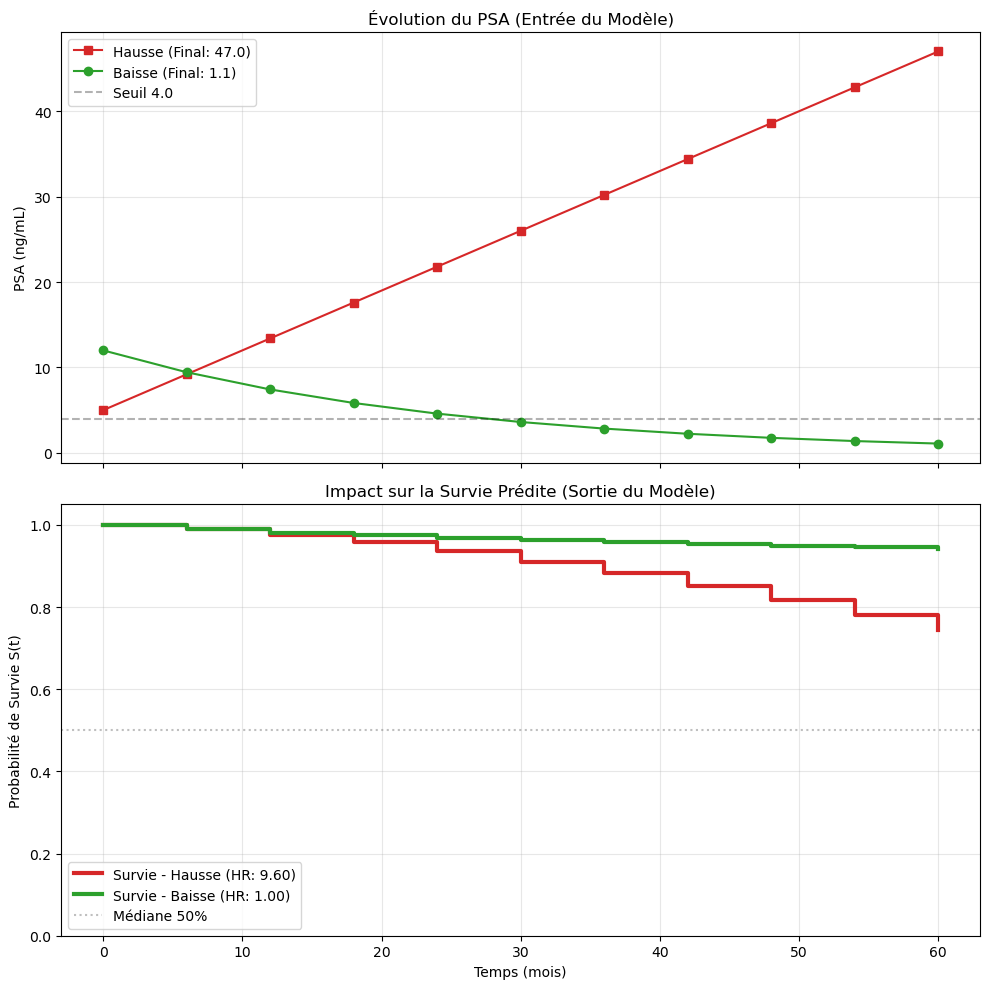

COMPARAISON FINALE À 60 MOIS :
Patient A (Hausse) : PSA final 47.0 | Risque relatif (HR) : 9.60
Patient B (Baisse) : PSA final 1.1 | Risque relatif (HR) : 1.00


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import dpsp  # Import simplifié tel que configuré dans __init__.py

# 1. Configuration initiale
model = DynamicSurvivalModel(threshold=4.0)
temps = np.arange(0, 61, 6)

# --- SCÉNARIO A : Hausse (Progression) ---
psa_hausse = 5 + (0.7 * temps)
survie_hausse = model.predict_survival(temps, psa_hausse)
hr_hausse = model.get_hazard_ratio(psa_hausse[-1])

# --- SCÉNARIO B : Baisse (Réponse au traitement) ---
# On commence à 12 et on descend progressivement
psa_baisse = 12 * np.exp(-0.04 * temps) 
survie_baisse = model.predict_survival(temps, psa_baisse)
hr_baisse = model.get_hazard_ratio(psa_baisse[-1])

# 2. Graphique comparatif
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Graphique du PSA
ax1.plot(temps, psa_hausse, 's-', color='tab:red', label=f"Hausse (Final: {psa_hausse[-1]:.1f})")
ax1.plot(temps, psa_baisse, 'o-', color='tab:green', label=f"Baisse (Final: {psa_baisse[-1]:.1f})")
ax1.axhline(y=4.0, color='black', linestyle='--', alpha=0.3, label="Seuil 4.0")
ax1.set_ylabel("PSA (ng/mL)")
ax1.set_title("Évolution du PSA (Entrée du Modèle)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique de Survie
ax2.step(temps, survie_hausse, where='post', lw=3, color='tab:red', label=f"Survie - Hausse (HR: {hr_hausse:.2f})")
ax2.step(temps, survie_baisse, where='post', lw=3, color='tab:green', label=f"Survie - Baisse (HR: {hr_baisse:.2f})")
ax2.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label="Médiane 50%")
ax2.set_ylabel("Probabilité de Survie S(t)")
ax2.set_xlabel("Temps (mois)")
ax2.set_title("Impact sur la Survie Prédite (Sortie du Modèle)")
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Conclusion textuelle
print(f"COMPARAISON FINALE À 60 MOIS :")
print(f"Patient A (Hausse) : PSA final {psa_hausse[-1]:.1f} | Risque relatif (HR) : {hr_hausse:.2f}")
print(f"Patient B (Baisse) : PSA final {psa_baisse[-1]:.1f} | Risque relatif (HR) : {hr_baisse:.2f}")

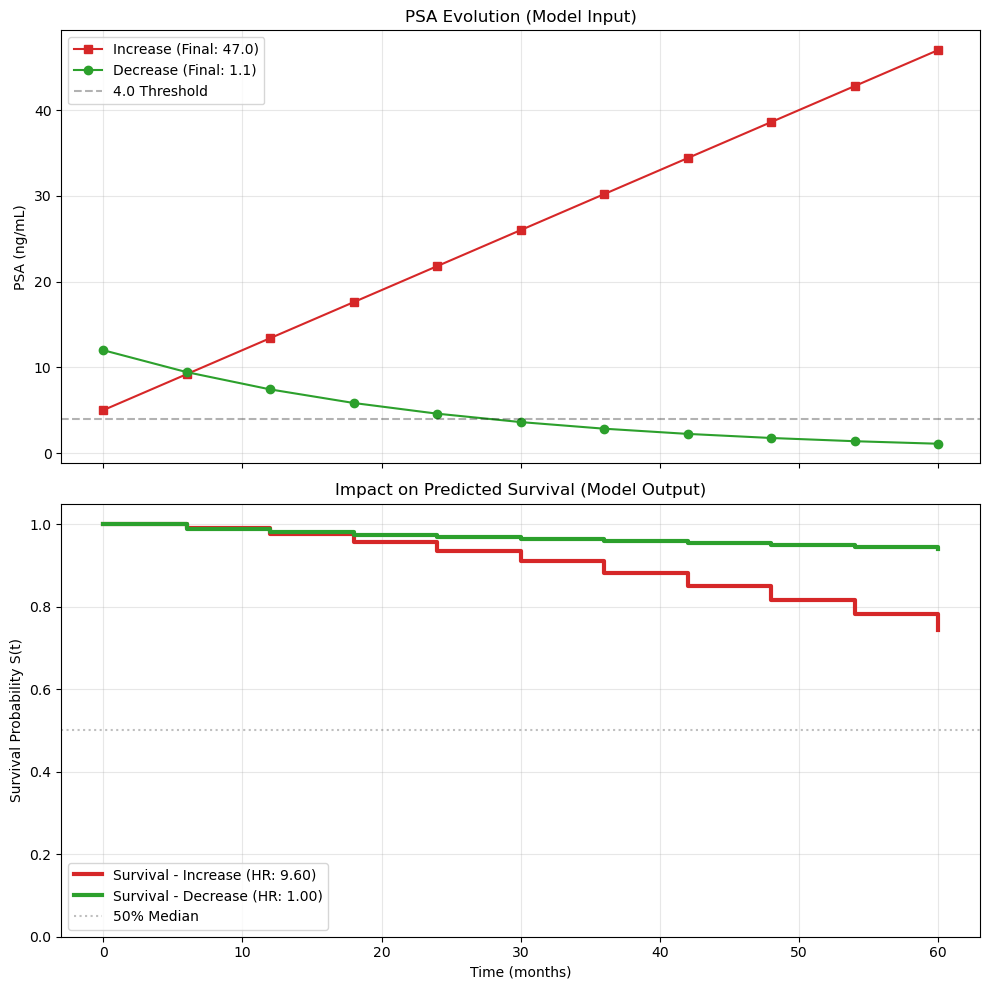

FINAL COMPARISON AT 60 MONTHS:
Patient A (Increase): Final PSA 47.0 | Hazard Ratio (HR): 9.60
Patient B (Decrease): Final PSA 1.1 | Hazard Ratio (HR): 1.00


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import dpsp  # Simplified import from your __init__.py setup

# 1. Initial Configuration
model = dpsp.DynamicSurvivalModel(threshold=4.0)
temps = np.arange(0, 61, 6)

# --- SCENARIO A: Increase (Progression) ---
psa_hausse = 5 + (0.7 * temps)
survie_hausse = model.predict_survival(temps, psa_hausse)
hr_hausse = model.get_hazard_ratio(psa_hausse[-1])

# --- SCENARIO B: Decrease (Treatment Response) ---
# Starting at 12 and decreasing exponentially
psa_baisse = 12 * np.exp(-0.04 * temps) 
survie_baisse = model.predict_survival(temps, psa_baisse)
hr_baisse = model.get_hazard_ratio(psa_baisse[-1])

# 2. Comparative Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# PSA Plot
ax1.plot(temps, psa_hausse, 's-', color='tab:red', label=f"Increase (Final: {psa_hausse[-1]:.1f})")
ax1.plot(temps, psa_baisse, 'o-', color='tab:green', label=f"Decrease (Final: {psa_baisse[-1]:.1f})")
ax1.axhline(y=4.0, color='black', linestyle='--', alpha=0.3, label="4.0 Threshold")
ax1.set_ylabel("PSA (ng/mL)")
ax1.set_title("PSA Evolution (Model Input)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Survival Plot
ax2.step(temps, survie_hausse, where='post', lw=3, color='tab:red', label=f"Survival - Increase (HR: {hr_hausse:.2f})")
ax2.step(temps, survie_baisse, where='post', lw=3, color='tab:green', label=f"Survival - Decrease (HR: {hr_baisse:.2f})")
ax2.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label="50% Median")
ax2.set_ylabel("Survival Probability S(t)")
ax2.set_xlabel("Time (months)")
ax2.set_title("Impact on Predicted Survival (Model Output)")
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Final Summary
print(f"FINAL COMPARISON AT 60 MONTHS:")
print(f"Patient A (Increase): Final PSA {psa_hausse[-1]:.1f} | Hazard Ratio (HR): {hr_hausse:.2f}")
print(f"Patient B (Decrease): Final PSA {psa_baisse[-1]:.1f} | Hazard Ratio (HR): {hr_baisse:.2f}")